In [6]:
import pandas as pd
import numpy as np
import joblib
import json
import time
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression, RFE
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directories
os.makedirs('results_v3/sensitivity_analysis', exist_ok=True)
os.makedirs('results_v3/sensitivity_analysis/figures', exist_ok=True)
os.makedirs('models_v3/sensitivity', exist_ok=True)

# ==================== Data Preparation ====================

def create_typhoon_features(df):
    """Create 19 physics-informed typhoon features"""
    df = df.copy()
    
    df['typhoon_active'] = (df['台风等级'] != 0).astype(int)
    
    def map_intensity(val):
        if pd.isna(val) or val == 0 or val == '0':
            return 0
        val_str = str(val).upper()
        mapping = {'TD': 1, '热带低压': 1, 'TS': 2, '热带风暴': 2, 'STS': 3, 
                   '强热带风暴': 3, 'TY': 4, '台风': 4, '强台风': 5, 'STY': 6, '超强台风': 6}
        for key, value in mapping.items():
            if key in val_str:
                return value
        try:
            return float(val)
        except:
            return 0
    
    df['typhoon_intensity_coded'] = df['台风强度'].apply(map_intensity)
    df['typhoon_distance_impact'] = df.apply(
        lambda row: 1 / (1 + np.exp((row['距离博罗站'] - 250) / 50)) if row['距离博罗站'] > 0 else 0, axis=1)
    df['typhoon_composite_impact'] = df['风速'] * df['台风等级'] * df['typhoon_distance_impact']
    
    def classify_wind(speed):
        if speed == 0: return 0
        elif speed < 17.2: return 1
        elif speed < 24.5: return 2
        elif speed < 32.7: return 3
        elif speed < 41.5: return 4
        elif speed < 51.0: return 5
        else: return 6
    
    df['wind_force_class'] = df['风速'].apply(classify_wind)
    df['pressure_intensity'] = df.apply(
        lambda row: (1013.25 - row['气压']) / 50 if row['气压'] > 0 else 0, axis=1)
    df['typhoon_duration_days'] = df['台风起始距今天数']
    df['typhoon_accum_3day'] = df['typhoon_active'].rolling(window=3, min_periods=1).sum()
    df['typhoon_accum_7day'] = df['typhoon_active'].rolling(window=7, min_periods=1).sum()
    df['typhoon_intensity_accum_3day'] = df['typhoon_composite_impact'].rolling(window=3, min_periods=1).mean()
    df['typhoon_intensity_accum_7day'] = df['typhoon_composite_impact'].rolling(window=7, min_periods=1).mean()
    df['typhoon_lon_change'] = df['台风经度'].diff().fillna(0)
    df['typhoon_lat_change'] = df['台风纬度'].diff().fillna(0)
    df['typhoon_move_speed'] = np.sqrt(df['typhoon_lon_change']**2 + df['typhoon_lat_change']**2)
    
    boluo_lon, boluo_lat = 114.2967, 23.15881
    df['typhoon_relative_lon'] = df['台风经度'] - boluo_lon
    df['typhoon_relative_lat'] = df['台风纬度'] - boluo_lat
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['is_typhoon_season'] = df['month'].isin([6, 7, 8, 9, 10]).astype(int)
    df['typhoon_seasonal_intensity'] = df['typhoon_composite_impact'] * df['is_typhoon_season']
    
    return df

def prepare_data_baseline(data_file, lag_days=7):
    """Prepare baseline dataset WITHOUT any typhoon features"""
    print("\n[Baseline] Preparing data WITHOUT typhoon features...")
    df = pd.read_csv(data_file)
    numeric_columns = df.select_dtypes(include=['number']).columns
    df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)
    
    # Exclude typhoon and unnecessary columns
    exclude_cols = ['date', '博罗站流量', '台风起始距今天数', '台风经度', '台风纬度', 
                    '台风等级', '台风强度', '风速', '气压', '距离博罗站',
                    '白盆珠出库流量', '博罗', '博罗_T', '博罗_p', '博罗_E', '安墩', '大陂布', '平山']
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    features, labels = [], []
    for i in range(len(df) - lag_days):
        feature = df[feature_cols].iloc[i:i + lag_days].values.flatten()
        label = df['博罗站流量'].iloc[i + lag_days]
        features.append(feature)
        labels.append(label)
    
    feature_names = [f'{col}(T-{day})' for day in range(1, lag_days + 1) for col in feature_cols]
    X = pd.DataFrame(features, columns=feature_names)
    y = pd.Series(labels, name='博罗站流量')
    dates = df['date'][lag_days:].reset_index(drop=True)
    
    print(f"  Features: {len(feature_names)}")
    return X, y, dates, feature_names

def prepare_data_with_typhoon(data_file, lag_days=7):
    """Prepare dataset WITH all 19 typhoon features"""
    print("\n[With Typhoon] Preparing data WITH 19 typhoon features...")
    df = pd.read_csv(data_file)
    numeric_columns = df.select_dtypes(include=['number']).columns
    df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)
    df = create_typhoon_features(df)
    
    # Define 19 typhoon feature columns
    typhoon_features = [
        'typhoon_active', 'typhoon_intensity_coded', 'typhoon_distance_impact',
        'typhoon_composite_impact', 'wind_force_class', 'pressure_intensity',
        'typhoon_duration_days', 'typhoon_accum_3day', 'typhoon_accum_7day',
        'typhoon_intensity_accum_3day', 'typhoon_intensity_accum_7day',
        'typhoon_lon_change', 'typhoon_lat_change', 'typhoon_move_speed',
        'typhoon_relative_lon', 'typhoon_relative_lat', 'month',
        'is_typhoon_season', 'typhoon_seasonal_intensity'
    ]
    
    # Exclude original typhoon columns and unnecessary columns
    exclude_cols = ['date', '博罗站流量', '台风起始距今天数', '台风经度', '台风纬度', 
                    '台风等级', '台风强度', '风速', '气压']
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    features, labels = [], []
    for i in range(len(df) - lag_days):
        feature = df[feature_cols].iloc[i:i + lag_days].values.flatten()
        label = df['博罗站流量'].iloc[i + lag_days]
        features.append(feature)
        labels.append(label)
    
    feature_names = [f'{col}(T-{day})' for day in range(1, lag_days + 1) for col in feature_cols]
    X = pd.DataFrame(features, columns=feature_names)
    y = pd.Series(labels, name='博罗站流量')
    dates = df['date'][lag_days:].reset_index(drop=True)
    
    # Identify typhoon feature indices
    typhoon_indices = [i for i, name in enumerate(feature_names) 
                       if any(tf in name for tf in typhoon_features)]
    
    print(f"  Total features: {len(feature_names)}")
    print(f"  Typhoon features: {len(typhoon_indices)} (19 × {lag_days} time lags)")
    
    return X, y, dates, feature_names, typhoon_indices

def split_data(X, y, dates, train_end='2004-12-31', test_start='2005-01-01'):
    """Split data into train and test sets"""
    train_mask = dates <= train_end
    test_mask = dates >= test_start
    
    X_train = X[train_mask].reset_index(drop=True)
    y_train = y[train_mask].reset_index(drop=True)
    X_test = X[test_mask].reset_index(drop=True)
    y_test = y[test_mask].reset_index(drop=True)
    dates_test = dates[test_mask].reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test, dates_test

# ==================== Feature Analysis on Typhoon Features ====================

def analyze_typhoon_correlation(X_typhoon, feature_names):
    """Analyze correlation among 19 typhoon features"""
    print("\n" + "="*80)
    print("Typhoon Feature Correlation Analysis")
    print("="*80)
    
    base_features = sorted(list(set([name.split('(T-')[0] for name in feature_names])))
    print(f"\nAnalyzing {len(base_features)} unique typhoon features across time lags")
    
    # Cross-correlation between different features (at same time lag)
    time_lag_corr_matrices = {}
    
    for lag in range(1, 8):
        lag_features = [col for col in feature_names if col.endswith(f'(T-{lag})')]
        lag_X = X_typhoon[lag_features]
        lag_X.columns = [col.split('(T-')[0] for col in lag_X.columns]
        lag_corr = lag_X.corr()
        time_lag_corr_matrices[f'T-{lag}'] = lag_corr
    
    # Average correlation across all time lags
    avg_cross_corr = sum(time_lag_corr_matrices.values()) / len(time_lag_corr_matrices)
    
    # Find highly correlated feature pairs
    high_cross_corr = []
    for i in range(len(base_features)):
        for j in range(i+1, len(base_features)):
            corr_val = avg_cross_corr.iloc[i, j]
            if abs(corr_val) > 0.6:
                high_cross_corr.append({
                    'feature1': base_features[i],
                    'feature2': base_features[j],
                    'avg_correlation': corr_val
                })
    
    print(f"\nHigh cross-correlations between features (|r| > 0.6): {len(high_cross_corr)}")
    sorted_cross = sorted(high_cross_corr, key=lambda x: abs(x['avg_correlation']), reverse=True)
    for idx, pair in enumerate(sorted_cross[:10], 1):
        print(f"  {idx:2d}. {pair['feature1']:35} <-> {pair['feature2']:35}: {pair['avg_correlation']:6.3f}")
    
    avg_cross_corr.to_csv('results_v3/sensitivity_analysis/typhoon_cross_correlation_19x19.csv')
    
    # Visualization
    plt.figure(figsize=(16, 14))
    mask = np.triu(np.ones_like(avg_cross_corr, dtype=bool), k=1)
    sns.heatmap(avg_cross_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
                vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'},
                linewidths=0.5, linecolor='gray')
    plt.title('Cross-correlation Between 19 Typhoon Features\n(averaged across time lags T-1 to T-7)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Typhoon Features', fontsize=11)
    plt.ylabel('Typhoon Features', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('results_v3/sensitivity_analysis/figures/typhoon_cross_correlation_heatmap.png', 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    return avg_cross_corr, high_cross_corr

def compute_feature_importance(X_train, y_train, X_test, y_test, feature_names):
    """Compute feature importance using multiple methods"""
    print("\n" + "="*80)
    print("Feature Importance Analysis")
    print("="*80)
    
    # Mutual Information
    print("\n[1/3] Mutual Information...")
    mi_scores = mutual_info_regression(X_train, y_train, random_state=42, n_neighbors=3)
    mi_df = pd.DataFrame({
        'feature': feature_names,
        'mi_score': mi_scores,
        'rank': pd.Series(mi_scores).rank(ascending=False, method='min')
    }).sort_values('mi_score', ascending=False)
    
    print(f"Top 10 features:")
    print(mi_df.head(10)[['feature', 'mi_score']].to_string(index=False))
    
    # RFE
    print("\n[2/3] Recursive Feature Elimination...")
    n_select = min(50, len(feature_names))
    estimator = LinearRegression()
    rfe = RFE(estimator=estimator, n_features_to_select=n_select, step=10)
    rfe.fit(X_train, y_train)
    
    rfe_df = pd.DataFrame({
        'feature': feature_names,
        'selected': rfe.support_,
        'rank': rfe.ranking_
    }).sort_values('rank')
    
    selected_features = rfe_df[rfe_df['selected']]['feature'].tolist()
    print(f"Selected {len(selected_features)} features")
    
    # Random Forest
    print("\n[3/3] Random Forest Importance...")
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    rf_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_,
        'rank': pd.Series(rf.feature_importances_).rank(ascending=False, method='min')
    }).sort_values('importance', ascending=False)
    
    print(f"Top 10 features:")
    print(rf_df.head(10)[['feature', 'importance']].to_string(index=False))
    
    # Save results
    mi_df.to_csv('results_v3/sensitivity_analysis/mutual_information_scores.csv', index=False)
    rfe_df.to_csv('results_v3/sensitivity_analysis/rfe_rankings.csv', index=False)
    rf_df.to_csv('results_v3/sensitivity_analysis/rf_importance_scores.csv', index=False)
    
    # Consensus features
    top_mi = set(mi_df.head(30)['feature'].tolist())
    top_rfe = set(rfe_df.head(30)['feature'].tolist())
    top_rf = set(rf_df.head(30)['feature'].tolist())
    consensus = list(top_mi & top_rfe & top_rf)
    
    print(f"\nConsensus features (in top 30 of all methods): {len(consensus)}")
    
    return mi_df, rfe_df, rf_df, selected_features, consensus

# ==================== Model Training ====================

def get_models():
    """Define 4 models with fixed hyperparameters"""
    return {
        'LR': LinearRegression(),
        'ANN': MLPRegressor(hidden_layer_sizes=(128,), activation='relu', 
                           alpha=0.001, max_iter=2000, random_state=42, early_stopping=True),
        'RF': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=2,
                                   min_samples_leaf=1, max_features='sqrt', random_state=42, n_jobs=-1),
        'XGB': XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    }

def evaluate_model(y_true, y_pred):
    """Calculate evaluation metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    
    mean_obs = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    std_obs = np.std(y_true)
    std_pred = np.std(y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1]
    kge = 1 - np.sqrt((r - 1)**2 + (std_pred/std_obs - 1)**2 + (mean_pred/mean_obs - 1)**2)
    
    return {'RMSE': rmse, 'MAE': mae, 'NSE': nse, 'KGE': kge}

def train_evaluate_models(X_train, X_test, y_train, y_test, scenario_name):
    """Train and evaluate all models"""
    print(f"\n{'='*80}")
    print(f"Training models: {scenario_name}")
    print(f"Features: {X_train.shape[1]}")
    print(f"{'='*80}")
    
    models = get_models()
    results = {}
    
    for name, model in models.items():
        print(f"\n  [{name}] Training...", end=' ')
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        inference_start = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - inference_start
        
        metrics = evaluate_model(y_test, y_pred)
        
        print(f"Done. NSE: {metrics['NSE']:.4f}, RMSE: {metrics['RMSE']:.2f}")
        
        results[name] = {
            'metrics': metrics,
            'train_time': train_time,
            'inference_time': inference_time,
            'predictions': y_pred
        }
        
        joblib.dump(model, f'models_v3/sensitivity/{scenario_name}_{name}.pkl')
    
    return results

# ==================== Comparison ====================

def print_comparison_table(all_results):
    """Print comprehensive comparison table"""
    models = ['LR', 'ANN', 'RF', 'XGB']
    scenarios = list(all_results.keys())
    metrics = ['NSE', 'RMSE', 'MAE', 'KGE']
    
    print("\n" + "="*120)
    print("COMPREHENSIVE PERFORMANCE COMPARISON")
    print("="*120)
    
    for metric in metrics:
        print(f"\n【{metric}】")
        print("-"*120)
        
        # Header
        header = f"{'Model':<8}"
        for scenario in scenarios:
            n_feat = all_results[scenario]['n_features']
            header += f" {scenario[:15]:>18} (n={n_feat})"
        print(header)
        print("-"*120)
        
        # Data rows
        for model in models:
            row = f"{model:<8}"
            baseline_val = all_results[scenarios[0]]['results'][model]['metrics'][metric]
            
            for scenario in scenarios:
                val = all_results[scenario]['results'][model]['metrics'][metric]
                
                # Calculate improvement
                if metric in ['RMSE', 'MAE']:
                    improvement = (baseline_val - val) / baseline_val * 100
                else:
                    improvement = (val - baseline_val) / abs(baseline_val + 1e-10) * 100
                
                if scenario == scenarios[0]:  # Baseline
                    row += f" {val:>18.4f}"
                else:
                    row += f" {val:>8.4f} ({improvement:+6.1f}%)"
            
            print(row)
        print("-"*120)
    
    # Feature count summary
    print("\n【Feature Count Summary】")
    print("-"*120)
    for scenario in scenarios:
        n_feat = all_results[scenario]['n_features']
        pct = (n_feat / all_results[scenarios[0]]['n_features']) * 100
        print(f"{scenario:30} {n_feat:>6} features ({pct:>6.1f}% of baseline)")
    print("-"*120)

def save_results(all_results):
    """Save all results to CSV and JSON"""
    models = ['LR', 'ANN', 'RF', 'XGB']
    scenarios = list(all_results.keys())
    
    # Create comparison dataframe
    rows = []
    for model in models:
        for scenario in scenarios:
            row = {
                'Model': model,
                'Scenario': scenario,
                'N_Features': all_results[scenario]['n_features'],
                'NSE': all_results[scenario]['results'][model]['metrics']['NSE'],
                'RMSE': all_results[scenario]['results'][model]['metrics']['RMSE'],
                'MAE': all_results[scenario]['results'][model]['metrics']['MAE'],
                'KGE': all_results[scenario]['results'][model]['metrics']['KGE'],
                'Train_Time_s': all_results[scenario]['results'][model]['train_time'],
                'Inference_Time_s': all_results[scenario]['results'][model]['inference_time']
            }
            rows.append(row)
    
    df = pd.DataFrame(rows)
    df.to_csv('results_v3/sensitivity_analysis/comprehensive_comparison.csv', index=False)
    
    # Save summary JSON
    with open('results_v3/sensitivity_analysis/comprehensive_results.json', 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=4, ensure_ascii=False, default=str)
    
    print("\n" + "="*120)
    print("Results saved to:")
    print("  - results_v3/sensitivity_analysis/comprehensive_comparison.csv")
    print("  - results_v3/sensitivity_analysis/comprehensive_results.json")

# ==================== Main ====================

def main():
    print("="*120)
    print("COMPREHENSIVE TYPHOON FEATURE SENSITIVITY ANALYSIS")
    print("Comparing: Baseline → +19 Typhoon Features → +RFE Selected → +MI Selected")
    print("="*120)
    
    data_file = '../数据/typhoon_daily_boluo.csv'
    
    # ========== Scenario 1: Baseline (No Typhoon Features) ==========
    print("\n" + "="*120)
    print("SCENARIO 1: Baseline (Without Typhoon Features)")
    print("="*120)
    
    X_baseline, y_baseline, dates_baseline, features_baseline = prepare_data_baseline(data_file)
    X_train_bl, X_test_bl, y_train_bl, y_test_bl, dates_test_bl = split_data(X_baseline, y_baseline, dates_baseline)
    
    results_baseline = train_evaluate_models(X_train_bl, X_test_bl, y_train_bl, y_test_bl, 'baseline')
    
    # ========== Scenario 2: With All Typhoon Features ==========
    print("\n" + "="*120)
    print("SCENARIO 2: Baseline + All 19 Typhoon Features")
    print("="*120)
    
    X_with_ty, y_with_ty, dates_with_ty, features_with_ty, typhoon_idx = prepare_data_with_typhoon(data_file)
    X_train_ty, X_test_ty, y_train_ty, y_test_ty, dates_test_ty = split_data(X_with_ty, y_with_ty, dates_with_ty)
    
    # Analyze typhoon features
    X_typhoon_only = X_train_ty.iloc[:, typhoon_idx]
    typhoon_feature_names = [features_with_ty[i] for i in typhoon_idx]
    
    print("\n" + "="*80)
    print("Analyzing 19 Typhoon Features")
    print("="*80)
    
    avg_corr, high_corr = analyze_typhoon_correlation(X_typhoon_only, typhoon_feature_names)
    mi_df, rfe_df, rf_df, rfe_selected, consensus = compute_feature_importance(
        X_typhoon_only, y_train_ty, X_test_ty.iloc[:, typhoon_idx], y_test_ty, typhoon_feature_names
    )
    
    results_with_typhoon = train_evaluate_models(X_train_ty, X_test_ty, y_train_ty, y_test_ty, 'with_all_typhoon')
    
    # ========== Scenario 3: With RFE Selected Typhoon Features ==========
    print("\n" + "="*120)
    print("SCENARIO 3: Baseline + RFE Selected Typhoon Features")
    print("="*120)
    
    # Get indices of baseline features + RFE selected typhoon features
    baseline_indices = [i for i in range(len(features_with_ty)) if i not in typhoon_idx]
    rfe_typhoon_indices = [features_with_ty.index(f) for f in rfe_selected if f in features_with_ty]
    rfe_indices = baseline_indices + rfe_typhoon_indices
    
    X_train_rfe = X_train_ty.iloc[:, rfe_indices]
    X_test_rfe = X_test_ty.iloc[:, rfe_indices]
    
    print(f"  Baseline features: {len(baseline_indices)}")
    print(f"  RFE selected typhoon features: {len(rfe_typhoon_indices)}")
    print(f"  Total: {len(rfe_indices)}")
    
    # Save RFE selected features
    with open('results_v3/sensitivity_analysis/rfe_selected_typhoon_features.txt', 'w') as f:
        f.write(f"RFE Selected {len(rfe_typhoon_indices)} Typhoon Features:\n\n")
        for feat in rfe_selected:
            f.write(feat + '\n')
    
    results_rfe = train_evaluate_models(X_train_rfe, X_test_rfe, y_train_ty, y_test_ty, 'with_rfe_typhoon')
    
    # ========== Scenario 4: With MI Selected Typhoon Features ==========
    print("\n" + "="*120)
    print("SCENARIO 4: Baseline + MI Top Selected Typhoon Features")
    print("="*120)
    
    # Get top MI features (same number as RFE for fair comparison)
    n_select_mi = len(rfe_selected)
    mi_selected = mi_df.head(n_select_mi)['feature'].tolist()
    
    mi_typhoon_indices = [features_with_ty.index(f) for f in mi_selected if f in features_with_ty]
    mi_indices = baseline_indices + mi_typhoon_indices
    
    X_train_mi = X_train_ty.iloc[:, mi_indices]
    X_test_mi = X_test_ty.iloc[:, mi_indices]
    
    print(f"  Baseline features: {len(baseline_indices)}")
    print(f"  MI selected typhoon features: {len(mi_typhoon_indices)}")
    print(f"  Total: {len(mi_indices)}")
    
    # Save MI selected features
    with open('results_v3/sensitivity_analysis/mi_selected_typhoon_features.txt', 'w') as f:
        f.write(f"MI Top {len(mi_typhoon_indices)} Typhoon Features:\n\n")
        for feat in mi_selected:
            f.write(feat + '\n')
    
    results_mi = train_evaluate_models(X_train_mi, X_test_mi, y_train_ty, y_test_ty, 'with_mi_typhoon')
    
    # ========== Compile All Results ==========
    all_results = {
        '1_Baseline': {
            'n_features': len(features_baseline),
            'description': 'Without any typhoon features',
            'results': results_baseline
        },
        '2_With_All_Typhoon': {
            'n_features': len(features_with_ty),
            'description': f'Baseline + all 19 typhoon features ({len(typhoon_idx)} with time lags)',
            'results': results_with_typhoon
        },
        '3_With_RFE_Typhoon': {
            'n_features': len(rfe_indices),
            'description': f'Baseline + {len(rfe_typhoon_indices)} RFE selected typhoon features',
            'results': results_rfe
        },
        '4_With_MI_Typhoon': {
            'n_features': len(mi_indices),
            'description': f'Baseline + {len(mi_typhoon_indices)} MI top selected typhoon features',
            'results': results_mi
        }
    }
    
    # ========== Analyze Feature Selection Overlap ==========
    print("\n" + "="*120)
    print("Feature Selection Method Comparison")
    print("="*120)
    
    rfe_set = set(rfe_selected)
    mi_set = set(mi_selected)
    overlap = rfe_set & mi_set
    
    print(f"\nRFE selected: {len(rfe_selected)} features")
    print(f"MI selected: {len(mi_selected)} features")
    print(f"Overlap: {len(overlap)} features ({len(overlap)/len(rfe_selected)*100:.1f}%)")
    print(f"RFE only: {len(rfe_set - mi_set)} features")
    print(f"MI only: {len(mi_set - rfe_set)} features")
    
    if len(overlap) > 0:
        print(f"\nOverlapping features (selected by both methods):")
        for i, feat in enumerate(sorted(list(overlap))[:20], 1):
            print(f"  {i:2d}. {feat}")
    
    # Save feature selection comparison
    selection_comparison = {
        'rfe_selected': rfe_selected,
        'mi_selected': mi_selected,
        'overlap': list(overlap),
        'rfe_only': list(rfe_set - mi_set),
        'mi_only': list(mi_set - rfe_set),
        'n_rfe': len(rfe_selected),
        'n_mi': len(mi_selected),
        'n_overlap': len(overlap),
        'overlap_percentage': len(overlap)/len(rfe_selected)*100
    }
    
    with open('results_v3/sensitivity_analysis/feature_selection_comparison.json', 'w', encoding='utf-8') as f:
        json.dump(selection_comparison, f, indent=4, ensure_ascii=False)
    
    # ========== Print and Save Results ==========
    print_comparison_table(all_results)
    save_results(all_results)
    
    # ========== Summary Statistics ==========
    print("\n" + "="*120)
    print("ANALYSIS COMPLETE!")
    print("="*120)
    print("\nKey Findings:")
    print(f"1. Baseline features: {len(features_baseline)}")
    print(f"2. Adding all 19 typhoon features: {len(features_with_ty)} total features")
    print(f"3. Typhoon feature correlation analysis:")
    print(f"   - High correlations found: {len(high_corr)} pairs (|r| > 0.6)")
    print(f"4. Feature selection:")
    print(f"   - RFE selected: {len(rfe_typhoon_indices)} typhoon features")
    print(f"   - MI selected: {len(mi_typhoon_indices)} typhoon features")
    print(f"   - Overlap: {len(overlap)} features ({len(overlap)/len(rfe_selected)*100:.1f}%)")
    print(f"5. Consensus features (top 30 in all 3 methods): {len(consensus)}")
    
    # Calculate average improvements
    baseline_avg_nse = np.mean([results_baseline[m]['metrics']['NSE'] for m in ['LR', 'ANN', 'RF', 'XGB']])
    full_avg_nse = np.mean([results_with_typhoon[m]['metrics']['NSE'] for m in ['LR', 'ANN', 'RF', 'XGB']])
    rfe_avg_nse = np.mean([results_rfe[m]['metrics']['NSE'] for m in ['LR', 'ANN', 'RF', 'XGB']])
    mi_avg_nse = np.mean([results_mi[m]['metrics']['NSE'] for m in ['LR', 'ANN', 'RF', 'XGB']])
    
    print(f"\n6. Average NSE across 4 models:")
    print(f"   - Baseline: {baseline_avg_nse:.4f}")
    print(f"   - +All typhoon: {full_avg_nse:.4f} ({(full_avg_nse-baseline_avg_nse)/baseline_avg_nse*100:+.2f}%)")
    print(f"   - +RFE selected: {rfe_avg_nse:.4f} ({(rfe_avg_nse-baseline_avg_nse)/baseline_avg_nse*100:+.2f}%)")
    print(f"   - +MI selected: {mi_avg_nse:.4f} ({(mi_avg_nse-baseline_avg_nse)/baseline_avg_nse*100:+.2f}%)")
    
    print("\nAll results saved to: results_v3/sensitivity_analysis/")

if __name__ == "__main__":
    main()

COMPREHENSIVE TYPHOON FEATURE SENSITIVITY ANALYSIS
Comparing: Baseline → +19 Typhoon Features → +RFE Selected → +MI Selected

SCENARIO 1: Baseline (Without Typhoon Features)

[Baseline] Preparing data WITHOUT typhoon features...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8528\2461738792.py:85: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)


  Features: 84

Training models: baseline
Features: 84

  [LR] Training... Done. NSE: 0.9250, RMSE: 211.36

Done. NSE: 0.9236, RMSE: 213.28

Done. NSE: 0.8296, RMSE: 318.47

Done. NSE: 0.8885, RMSE: 257.63

SCENARIO 2: Baseline + All 19 Typhoon Features

[With Typhoon] Preparing data WITH 19 typhoon features...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8528\2461738792.py:114: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)


  Total features: 273
  Typhoon features: 133 (19 × 7 time lags)

Analyzing 19 Typhoon Features

Typhoon Feature Correlation Analysis

Analyzing 19 unique typhoon features across time lags

High cross-correlations between features (|r| > 0.6): 48
   1. is_typhoon_season                   <-> typhoon_move_speed                 :  1.000
   2. typhoon_move_speed                  <-> typhoon_relative_lat               :  0.996
   3. is_typhoon_season                   <-> typhoon_relative_lat               :  0.996
   4. typhoon_intensity_coded             <-> typhoon_lat_change                 :  0.993
   5. typhoon_accum_7day                  <-> typhoon_active                     :  0.980
   6. typhoon_accum_3day                  <-> wind_force_class                   :  0.979
   7. month                               <-> typhoon_accum_7day                 :  0.976
   8. month                               <-> typhoon_active                     :  0.961
   9. typhoon_accum_7day         

19 TYPHOON FEATURES CORRELATION HEATMAP

Reading data...
Creating typhoon features...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8528\1369618399.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)


Extracted 19 typhoon features
Data shape: (10592, 19)

Calculating correlation matrix...
Saved correlation matrix to CSV

Creating correlation heatmap...

Saved figure: results_v3/sensitivity_analysis/figures/19_features_correlation_lower_triangle.png


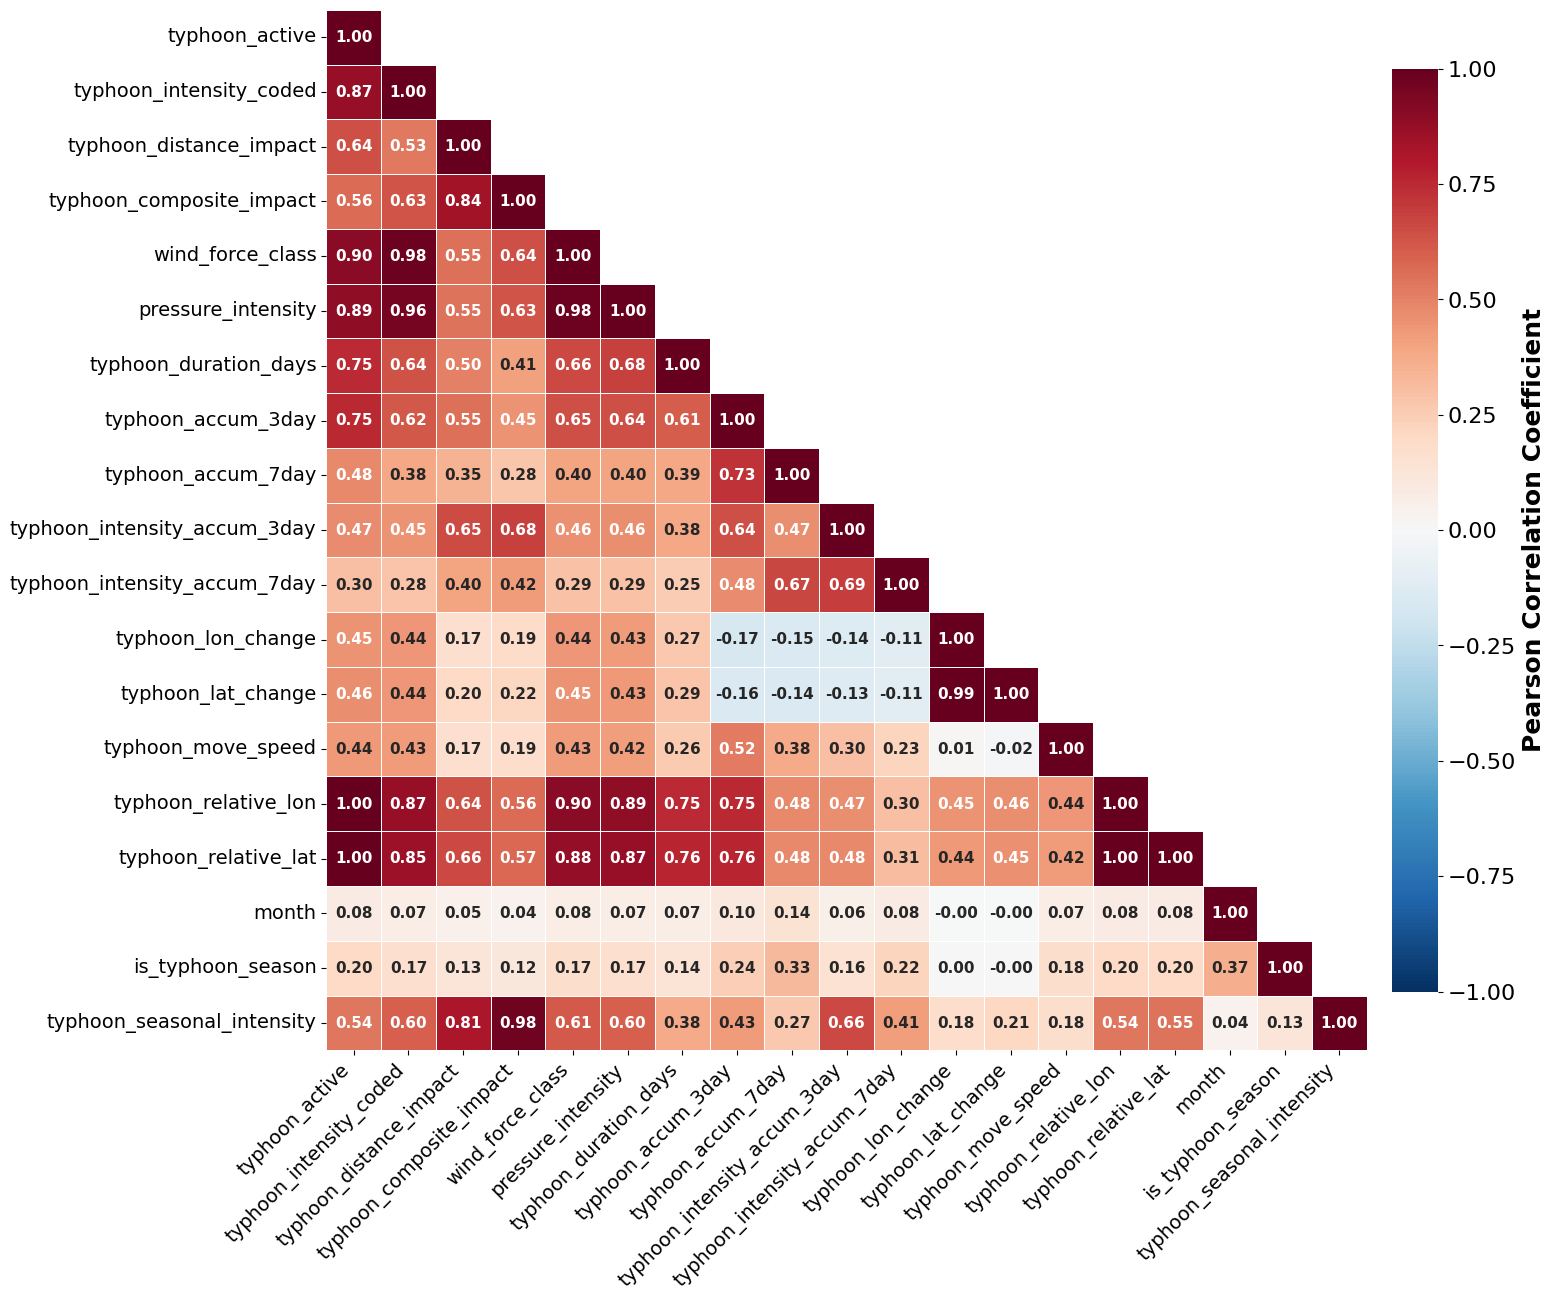


High Correlations (|r| > 0.6):
 1. typhoon_active                      <-> typhoon_intensity_coded            :  0.872
 2. typhoon_active                      <-> typhoon_distance_impact            :  0.641
 3. typhoon_active                      <-> wind_force_class                   :  0.899
 4. typhoon_active                      <-> pressure_intensity                 :  0.887
 5. typhoon_active                      <-> typhoon_duration_days              :  0.745
 6. typhoon_active                      <-> typhoon_accum_3day                 :  0.754
 7. typhoon_active                      <-> typhoon_relative_lon               :  1.000
 8. typhoon_active                      <-> typhoon_relative_lat               :  0.996
 9. typhoon_intensity_coded             <-> typhoon_composite_impact           :  0.632
10. typhoon_intensity_coded             <-> wind_force_class                   :  0.980
11. typhoon_intensity_coded             <-> pressure_intensity                 :  0.959


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory
os.makedirs('results_v3/sensitivity_analysis/figures', exist_ok=True)

# ==================== Data Preparation ====================

def create_typhoon_features(df):
    """Create 19 physics-informed typhoon features"""
    df = df.copy()
    
    df['typhoon_active'] = (df['台风等级'] != 0).astype(int)
    
    def map_intensity(val):
        if pd.isna(val) or val == 0 or val == '0':
            return 0
        val_str = str(val).upper()
        mapping = {'TD': 1, '热带低压': 1, 'TS': 2, '热带风暴': 2, 'STS': 3, 
                   '强热带风暴': 3, 'TY': 4, '台风': 4, '强台风': 5, 'STY': 6, '超强台风': 6}
        for key, value in mapping.items():
            if key in val_str:
                return value
        try:
            return float(val)
        except:
            return 0
    
    df['typhoon_intensity_coded'] = df['台风强度'].apply(map_intensity)
    df['typhoon_distance_impact'] = df.apply(
        lambda row: 1 / (1 + np.exp((row['距离博罗站'] - 250) / 50)) if row['距离博罗站'] > 0 else 0, axis=1)
    df['typhoon_composite_impact'] = df['风速'] * df['台风等级'] * df['typhoon_distance_impact']
    
    def classify_wind(speed):
        if speed == 0: return 0
        elif speed < 17.2: return 1
        elif speed < 24.5: return 2
        elif speed < 32.7: return 3
        elif speed < 41.5: return 4
        elif speed < 51.0: return 5
        else: return 6
    
    df['wind_force_class'] = df['风速'].apply(classify_wind)
    df['pressure_intensity'] = df.apply(
        lambda row: (1013.25 - row['气压']) / 50 if row['气压'] > 0 else 0, axis=1)
    df['typhoon_duration_days'] = df['台风起始距今天数']
    df['typhoon_accum_3day'] = df['typhoon_active'].rolling(window=3, min_periods=1).sum()
    df['typhoon_accum_7day'] = df['typhoon_active'].rolling(window=7, min_periods=1).sum()
    df['typhoon_intensity_accum_3day'] = df['typhoon_composite_impact'].rolling(window=3, min_periods=1).mean()
    df['typhoon_intensity_accum_7day'] = df['typhoon_composite_impact'].rolling(window=7, min_periods=1).mean()
    df['typhoon_lon_change'] = df['台风经度'].diff().fillna(0)
    df['typhoon_lat_change'] = df['台风纬度'].diff().fillna(0)
    df['typhoon_move_speed'] = np.sqrt(df['typhoon_lon_change']**2 + df['typhoon_lat_change']**2)
    
    boluo_lon, boluo_lat = 114.2967, 23.15881
    df['typhoon_relative_lon'] = df['台风经度'] - boluo_lon
    df['typhoon_relative_lat'] = df['台风纬度'] - boluo_lat
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['is_typhoon_season'] = df['month'].isin([6, 7, 8, 9, 10]).astype(int)
    df['typhoon_seasonal_intensity'] = df['typhoon_composite_impact'] * df['is_typhoon_season']
    
    return df

# ==================== Main ====================

def main():
    print("="*80)
    print("19 TYPHOON FEATURES CORRELATION HEATMAP")
    print("="*80)
    
    # Read and prepare data
    print("\nReading data...")
    data_file = '../数据/typhoon_daily_boluo.csv'
    df = pd.read_csv(data_file)
    
    # Preprocess
    numeric_columns = df.select_dtypes(include=['number']).columns
    df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)
    
    # Create typhoon features
    print("Creating typhoon features...")
    df = create_typhoon_features(df)
    
    # Define 19 typhoon features
    typhoon_features = [
        'typhoon_active',
        'typhoon_intensity_coded',
        'typhoon_distance_impact',
        'typhoon_composite_impact',
        'wind_force_class',
        'pressure_intensity',
        'typhoon_duration_days',
        'typhoon_accum_3day',
        'typhoon_accum_7day',
        'typhoon_intensity_accum_3day',
        'typhoon_intensity_accum_7day',
        'typhoon_lon_change',
        'typhoon_lat_change',
        'typhoon_move_speed',
        'typhoon_relative_lon',
        'typhoon_relative_lat',
        'month',
        'is_typhoon_season',
        'typhoon_seasonal_intensity'
    ]
    
    # Extract these features
    df_typhoon = df[typhoon_features].copy()
    
    print(f"Extracted {len(typhoon_features)} typhoon features")
    print(f"Data shape: {df_typhoon.shape}")
    
    # Calculate correlation matrix
    print("\nCalculating correlation matrix...")
    corr_matrix = df_typhoon.corr()
    
    # Save correlation matrix
    corr_matrix.to_csv('results_v3/sensitivity_analysis/19_features_correlation_matrix.csv')
    print("Saved correlation matrix to CSV")
    
    # Create lower triangle heatmap with optimized font sizes
    print("\nCreating correlation heatmap...")
    
    # Set up the matplotlib figure with larger size
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    # Create heatmap with larger fonts
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                fmt='.2f', 
                cmap='RdBu_r', 
                center=0, 
                vmin=-1, 
                vmax=1, 
                square=True,
                linewidths=0.5,
                linecolor='white',
                cbar_kws={'label': 'Pearson Correlation Coefficient', 
                         'shrink': 0.8,
                         'pad': 0.02},
                annot_kws={'size': 11, 'weight': 'bold'},  # Larger annotation font
                ax=ax)
    
    
    # Set tick labels with larger font
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
    
    # Adjust colorbar label font
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Pearson Correlation Coefficient', fontsize=18, weight='bold')
    
    # Tight layout
    plt.tight_layout()
    
    # Save figure
    output_file = 'results_v3/sensitivity_analysis/figures/19_features_correlation_lower_triangle.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved figure: {output_file}")
    
    plt.show()
    
    # Print high correlations
    print("\n" + "="*80)
    print("High Correlations (|r| > 0.6):")
    print("="*80)
    
    high_corr_count = 0
    for i in range(len(typhoon_features)):
        for j in range(i+1, len(typhoon_features)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.6:
                high_corr_count += 1
                print(f"{high_corr_count:2d}. {typhoon_features[i]:35} <-> {typhoon_features[j]:35}: {corr_val:6.3f}")
    
    print(f"\nTotal high correlations: {high_corr_count}")
    print("\n" + "="*80)
    print("COMPLETE!")
    print("="*80)

if __name__ == "__main__":
    main()